# Monitoring Seasonal Snow-Cover Variability in the Western Everest Region Using Sentinel-2, Unsupervised Classification and Gaussian Process Gap-Filling

## Notebook 2: Sentinel-2 Snow-Cover Mapping and Unsupervised Classification

This notebook processes the downloaded Sentinel-2 Level-2A data and converts them into monthly snow-cover estimates for the selected Everest region AOI. The workflow clips the images to the study area, applies cloud and invalid-pixel masking, calculates snow-related spectral indices, compares a traditional NDSI-threshold baseline with K-means unsupervised classification, and uses an example Gaussian mixture models (GMM, also a kind of unsupervised learning method) to further support the utility of K-means.

Another main output of this notebook is a monthly snow-cover fraction time series for 2025, which is then used in the Notebook 3 for Gaussian Process interpolation and artificial gap validation.

## 1. Set up workspace and load selected Sentinel-2 data

This step prepares the working environment for the snow-cover mapping. Google Drive is mounted, the main project folders are defined, and the table of selected monthly Sentinel-2 products from the Notebook 1 is loaded.

Each selected product is then matched to its extracted `.SAFE` folder in Google Drive. The resulting file paths are added to the product table so that the image bands can be located and processed in the following steps.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os
import glob
import pandas as pd
from IPython.display import display

In [3]:
project_dir = "/content/drive/MyDrive/GEOL0069/Final_Project"

data_dir = os.path.join(project_dir, "Data")
raw_dir = os.path.join(data_dir, "Raw")
safe_dir = os.path.join(raw_dir, "SAFE")
processed_dir = os.path.join(data_dir, "Processed")
metadata_dir = os.path.join(data_dir, "Metadata")
figures_dir = os.path.join(project_dir, "Figures")

print("SAFE directory:", safe_dir)
print("Metadata directory:", metadata_dir)

SAFE directory: /content/drive/MyDrive/GEOL0069/Final_Project/Data/Raw/SAFE
Metadata directory: /content/drive/MyDrive/GEOL0069/Final_Project/Data/Metadata


In [4]:
selected_products_path = os.path.join(metadata_dir, "selected_monthly_products_2025.csv")

selected_products = pd.read_csv(selected_products_path)

selected_products["date"] = pd.to_datetime(selected_products["date"])
selected_products["month"] = selected_products["month"].astype(int)
selected_products["month_name"] = selected_products["date"].dt.strftime("%B")

display(selected_products)

,month,date,product_id,product_name,cloud_cover,mgrs_tile,Online,download_status,S3Path,month_name
0,1,2025-01-31,a940528c-91d5-485c-a17c-465935284530,S2B_MSIL2A_20250131T044939_N0511_R076_T45RVM_2...,0.002054,45RVM,True,not_downloaded,/eodata/Sentinel-2/MSI/L2A/2025/01/31/S2B_MSIL...,January
1,2,2025-02-10,0b8d069a-6bc9-4998-ab00-d94de4d69700,S2B_MSIL2A_20250210T044839_N0511_R076_T45RVM_2...,2.521034,45RVM,True,not_downloaded,/eodata/Sentinel-2/MSI/L2A/2025/02/10/S2B_MSIL...,February
2,3,2025-03-27,8b97a93f-be3a-4c89-bb7a-2d3530ccd3bd,S2C_MSIL2A_20250327T044721_N0511_R076_T45RVM_2...,0.010100,45RVM,True,not_downloaded,/eodata/Sentinel-2/MSI/L2A/2025/03/27/S2C_MSIL...,March
3,4,2025-04-21,9c63c11b-8120-4e2e-82d1-be8f01d1cd43,S2B_MSIL2A_20250421T044659_N0511_R076_T45RVM_2...,0.050823,45RVM,True,not_downloaded,/eodata/Sentinel-2/MSI/L2A/2025/04/21/S2B_MSIL...,April
4,5,2025-05-08,374dc337-8882-41e5-91a4-e0ca96d79418,S2A_MSIL2A_20250508T045231_N0511_R076_T45RVM_2...,19.816066,45RVM,True,not_downloaded,/eodata/Sentinel-2/MSI/L2A/2025/05/08/S2A_MSIL...,May
5,6,2025-06-10,5935ac4b-7fe6-40b8-8d50-7509baa71d77,S2B_MSIL2A_20250610T044659_N0511_R076_T45RVM_2...,1.850641,45RVM,True,not_downloaded,/eodata/Sentinel-2/MSI/L2A/2025/06/10/S2B_MSIL...,June
6,7,2025-07-07,5424cd5d-7568-4fd6-a277-fa46ed7a2556,S2A_MSIL2A_20250707T045241_N0511_R076_T45RVM_2...,12.159456,45RVM,True,not_downloaded,/eodata/Sentinel-2/MSI/L2A/2025/07/07/S2A_MSIL...,July
7,8,2025-08-19,fb972a2b-f5e5-4c72-b17f-7ddf3a0ded86,S2B_MSIL2A_20250819T044659_N0511_R076_T45RVM_2...,42.063248,45RVM,True,not_downloaded,/eodata/Sentinel-2/MSI/L2A/2025/08/19/S2B_MSIL...,August
8,9,2025-09-05,fe760223-6cf8-43a6-bd98-0094ff33b589,S2A_MSIL2A_20250905T045231_N0511_R076_T45RVM_2...,23.067698,45RVM,True,not_downloaded,/eodata/Sentinel-2/MSI/L2A/2025/09/05/S2A_MSIL...,September
9,10,2025-10-25,1e3da49c-5323-4210-b31d-e28ac001b454,S2A_MSIL2A_20251025T045241_N0511_R076_T45RVM_2...,0.058397,45RVM,True,not_downloaded,/eodata/Sentinel-2/MSI/L2A/2025/10/25/S2A_MSIL...,October


In [5]:
safe_folders = sorted(glob.glob(os.path.join(safe_dir, "*.SAFE")))

safe_folder_lookup = {
    os.path.basename(folder): folder
    for folder in safe_folders
}

safe_paths = []

for index, row in selected_products.iterrows():
    product_name = row["product_name"]

    if product_name in safe_folder_lookup:
        safe_paths.append(safe_folder_lookup[product_name])
    else:
        safe_paths.append(None)

selected_products["safe_path"] = safe_paths

display(selected_products[["month", "month_name", "date", "product_name", "cloud_cover", "mgrs_tile", "safe_path"]])

,month,month_name,date,product_name,cloud_cover,mgrs_tile,safe_path
0,1,January,2025-01-31,S2B_MSIL2A_20250131T044939_N0511_R076_T45RVM_2...,0.002054,45RVM,/content/drive/MyDrive/GEOL0069/Final_Project/...
1,2,February,2025-02-10,S2B_MSIL2A_20250210T044839_N0511_R076_T45RVM_2...,2.521034,45RVM,/content/drive/MyDrive/GEOL0069/Final_Project/...
2,3,March,2025-03-27,S2C_MSIL2A_20250327T044721_N0511_R076_T45RVM_2...,0.010100,45RVM,/content/drive/MyDrive/GEOL0069/Final_Project/...
3,4,April,2025-04-21,S2B_MSIL2A_20250421T044659_N0511_R076_T45RVM_2...,0.050823,45RVM,/content/drive/MyDrive/GEOL0069/Final_Project/...
4,5,May,2025-05-08,S2A_MSIL2A_20250508T045231_N0511_R076_T45RVM_2...,19.816066,45RVM,/content/drive/MyDrive/GEOL0069/Final_Project/...
5,6,June,2025-06-10,S2B_MSIL2A_20250610T044659_N0511_R076_T45RVM_2...,1.850641,45RVM,/content/drive/MyDrive/GEOL0069/Final_Project/...
6,7,July,2025-07-07,S2A_MSIL2A_20250707T045241_N0511_R076_T45RVM_2...,12.159456,45RVM,/content/drive/MyDrive/GEOL0069/Final_Project/...
7,8,August,2025-08-19,S2B_MSIL2A_20250819T044659_N0511_R076_T45RVM_2...,42.063248,45RVM,/content/drive/MyDrive/GEOL0069/Final_Project/...
8,9,September,2025-09-05,S2A_MSIL2A_20250905T045231_N0511_R076_T45RVM_2...,23.067698,45RVM,/content/drive/MyDrive/GEOL0069/Final_Project/...
9,10,October,2025-10-25,S2A_MSIL2A_20251025T045241_N0511_R076_T45RVM_2...,0.058397,45RVM,/content/drive/MyDrive/GEOL0069/Final_Project/...


## 2. Read Sentinel-2 bands at 20 m resolution

This step locates and reads the Sentinel-2 Level-2A bands needed for snow-cover mapping. All input layers are read from the `R20m` folder within each extracted `.SAFE` directory, so that the spectral bands and classification layer are on the same 20 m grid.

The bands used are:

- B02: Blue
- B03: Green
- B04: Red
- B8A: NIR (Resolution = 20m/px)
- B11: SWIR 1
- SCL: Scene Classification Layer

The 20 m grid is used because B11 and SCL are provided at 20 m resolution, while the visible and near-infrared bands are also available as resampled 20 m layers in the Level-2A data structure. Keeping all layers on the same grid avoids band-shape mismatches when calculating NDSI and NDVI, applying the cloud/invalid-pixel mask, and building the feature stack for K-means classification.

In [6]:
!pip install rasterio

import rasterio
import numpy as np

In [7]:
required_bands = {
    "B02": "Blue",
    "B03": "Green",
    "B04": "Red",
    "B8A": "NIR",
    "B11": "SWIR",
    "SCL": "Scene Classification Layer"
}

def find_20m_band_paths(safe_path):
    band_paths = {}

    for band in required_bands.keys():
        pattern = os.path.join(
            safe_path,
            "GRANULE",
            "*",
            "IMG_DATA",
            "R20m",
            f"*_{band}_20m.jp2"
        )

        matches = glob.glob(pattern)
        band_paths[band] = matches[0] if len(matches) > 0 else None

    return band_paths

In [8]:
band_path_records = []

for index, row in selected_products.iterrows():
    band_paths = find_20m_band_paths(row["safe_path"])

    record = {
        "month": row["month"],
        "month_name": row["month_name"],
        "date": row["date"],
        "product_name": row["product_name"],
        "cloud_cover": row["cloud_cover"],
        "safe_path": row["safe_path"]
    }

    for band, path in band_paths.items():
        record[f"{band}_path"] = path

    band_path_records.append(record)

band_paths_df = pd.DataFrame(band_path_records)

display(
    band_paths_df[
        ["month", "month_name", "B02_path", "B03_path", "B04_path", "B8A_path", "B11_path", "SCL_path"]
    ]
)

,month,month_name,B02_path,B03_path,B04_path,B8A_path,B11_path,SCL_path
0,1,January,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...
1,2,February,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...
2,3,March,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...
3,4,April,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...
4,5,May,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...
5,6,June,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...
6,7,July,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...
7,8,August,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...
8,9,September,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...
9,10,October,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...,/content/drive/MyDrive/GEOL0069/Final_Project/...


In [9]:
band_columns = [f"{band}_path" for band in required_bands.keys()]

missing_bands = band_paths_df[band_columns].isna().sum().sum()

# Check the spatial resolution using the first product as a representative example
resolution_check = {}

for band in required_bands.keys():
    with rasterio.open(band_paths_df.iloc[0][f"{band}_path"]) as src:
        resolution_check[band] = {
            "resolution": src.res,
            "shape": (src.height, src.width),
            "crs": src.crs.to_string()
        }

print("Missing band paths:", missing_bands)
print("Representative 20 m band check:")
display(pd.DataFrame(resolution_check).T)

band_paths_output = os.path.join(metadata_dir,"monthly_20m_band_paths_2025.csv")

band_paths_df.to_csv(band_paths_output, index=False)

print("Band path table saved to:")
print(band_paths_output)

Missing band paths: 0
Representative 20 m band check:


,resolution,shape,crs
B02,"(20.0, 20.0)","(5490, 5490)",EPSG:32645
B03,"(20.0, 20.0)","(5490, 5490)",EPSG:32645
B04,"(20.0, 20.0)","(5490, 5490)",EPSG:32645
B8A,"(20.0, 20.0)","(5490, 5490)",EPSG:32645
B11,"(20.0, 20.0)","(5490, 5490)",EPSG:32645
SCL,"(20.0, 20.0)","(5490, 5490)",EPSG:32645


Band path table saved to:
/content/drive/MyDrive/GEOL0069/Final_Project/Data/Metadata/monthly_20m_band_paths_2025.csv


## 3. Clip Sentinel-2 bands to the Everest AOI

This step clips the 20 m Sentinel-2 layers to the selected AOI. The clipped arrays are used in the following steps for cloud masking, spectral-index calculation, and snow-cover classification.

A June scene is plotted as an RGB example to visually check the study area after clipping.

In [10]:
from rasterio.mask import mask
from rasterio.warp import transform_geom
import matplotlib.pyplot as plt

# AOI in longitude-latitude coordinates, matching the Copernicus query polygon
everest_aoi_geojson = {
    "type": "Polygon",
    "coordinates": [[
        [86.85, 28.05],
        [86.97, 28.05],
        [86.97, 28.17],
        [86.85, 28.17],
        [86.85, 28.05]
    ]]
}

In [11]:
def clip_band_to_aoi(band_path, aoi_geojson):
    """
    Clip one raster band to the AOI.

    The AOI is first transformed from EPSG:4326 into the raster CRS,
    then rasterio.mask.mask is used to crop the band.
    """

    with rasterio.open(band_path) as src:
        # Transform AOI from lon/lat to the raster CRS
        aoi_in_raster_crs = transform_geom("EPSG:4326", src.crs, aoi_geojson)

        clipped_array, clipped_transform = mask(src, [aoi_in_raster_crs], crop=True)

        clipped_profile = src.profile.copy()
        clipped_profile.update({
            "height": clipped_array.shape[1],
            "width": clipped_array.shape[2],
            "transform": clipped_transform
        })

    return clipped_array[0], clipped_profile

In [12]:
clipped_records = []

for index, row in band_paths_df.iterrows():
    month_data = {
        "month": row["month"],
        "month_name": row["month_name"],
        "date": row["date"],
        "product_name": row["product_name"],
        "cloud_cover": row["cloud_cover"]
    }

    clipped_bands = {}

    for band in required_bands.keys():
        band_array, band_profile = clip_band_to_aoi(
            row[f"{band}_path"],
            everest_aoi_geojson
        )

        clipped_bands[band] = band_array

    # Save clipped arrays as one compressed file per month
    output_file = os.path.join(
        processed_dir,
        f"clipped_bands_2025_{int(row['month']):02d}_{row['month_name']}.npz"
    )

    np.savez_compressed(
    output_file,
    B02=clipped_bands["B02"],
    B03=clipped_bands["B03"],
    B04=clipped_bands["B04"],
    B8A=clipped_bands["B8A"],
    B11=clipped_bands["B11"],
    SCL=clipped_bands["SCL"]
    )

    month_data["clipped_file"] = output_file
    month_data["height"] = clipped_bands["B03"].shape[0]
    month_data["width"] = clipped_bands["B03"].shape[1]

    clipped_records.append(month_data)

clipped_files_df = pd.DataFrame(clipped_records)

display(clipped_files_df)

,month,month_name,date,product_name,cloud_cover,clipped_file,height,width
0,1,January,2025-01-31,S2B_MSIL2A_20250131T044939_N0511_R076_T45RVM_2...,0.002054,/content/drive/MyDrive/GEOL0069/Final_Project/...,666,591
1,2,February,2025-02-10,S2B_MSIL2A_20250210T044839_N0511_R076_T45RVM_2...,2.521034,/content/drive/MyDrive/GEOL0069/Final_Project/...,666,591
2,3,March,2025-03-27,S2C_MSIL2A_20250327T044721_N0511_R076_T45RVM_2...,0.010100,/content/drive/MyDrive/GEOL0069/Final_Project/...,666,591
3,4,April,2025-04-21,S2B_MSIL2A_20250421T044659_N0511_R076_T45RVM_2...,0.050823,/content/drive/MyDrive/GEOL0069/Final_Project/...,666,591
4,5,May,2025-05-08,S2A_MSIL2A_20250508T045231_N0511_R076_T45RVM_2...,19.816066,/content/drive/MyDrive/GEOL0069/Final_Project/...,666,591
5,6,June,2025-06-10,S2B_MSIL2A_20250610T044659_N0511_R076_T45RVM_2...,1.850641,/content/drive/MyDrive/GEOL0069/Final_Project/...,666,591
6,7,July,2025-07-07,S2A_MSIL2A_20250707T045241_N0511_R076_T45RVM_2...,12.159456,/content/drive/MyDrive/GEOL0069/Final_Project/...,666,591
7,8,August,2025-08-19,S2B_MSIL2A_20250819T044659_N0511_R076_T45RVM_2...,42.063248,/content/drive/MyDrive/GEOL0069/Final_Project/...,666,591
8,9,September,2025-09-05,S2A_MSIL2A_20250905T045231_N0511_R076_T45RVM_2...,23.067698,/content/drive/MyDrive/GEOL0069/Final_Project/...,666,591
9,10,October,2025-10-25,S2A_MSIL2A_20251025T045241_N0511_R076_T45RVM_2...,0.058397,/content/drive/MyDrive/GEOL0069/Final_Project/...,666,591


In [13]:
clipped_files_path = os.path.join(metadata_dir, "monthly_clipped_band_files_2025.csv")

clipped_files_df.to_csv(clipped_files_path, index=False)

print("Clipped file table saved to:")
print(clipped_files_path)

Clipped file table saved to:
/content/drive/MyDrive/GEOL0069/Final_Project/Data/Metadata/monthly_clipped_band_files_2025.csv


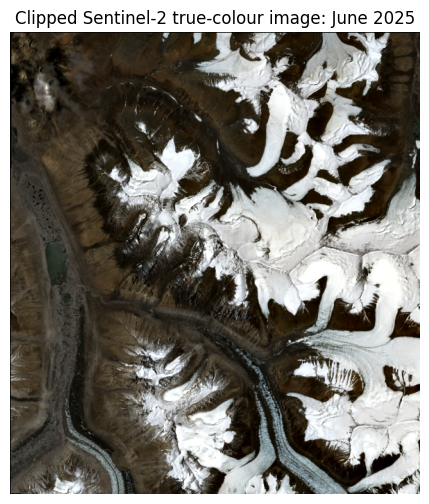

In [14]:
# Select a representative month for visual checking
# June has low cloud cover and clearer snow/rock contrast than October.
example_month = 6

example_file = clipped_files_df.loc[
    clipped_files_df["month"] == example_month,
    "clipped_file"
].iloc[0]

example_data = np.load(example_file)

# Convert Sentinel-2 scaled reflectance to float reflectance
red = example_data["B04"].astype(float) / 10000
green = example_data["B03"].astype(float) / 10000
blue = example_data["B02"].astype(float) / 10000

rgb = np.dstack([red, green, blue])

# Percentile stretch improves visual contrast and reduces snow overexposure
lower = np.nanpercentile(rgb, 2)
upper = np.nanpercentile(rgb, 98)

rgb_stretched = (rgb - lower) / (upper - lower)
rgb_stretched = np.clip(rgb_stretched, 0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(rgb_stretched)
plt.title("Clipped Sentinel-2 true-colour image: June 2025")
plt.axis("off")
plt.show()

## 4. Apply SCL mask and calculate spectral indices

This step first uses the Sentinel-2 Scene Classification Layer (SCL) to remove invalid, cloud-contaminated, and cloud-shadow pixels. The SCL layer is categorical, so it is used only as a mask and is not used to calculate spectral indices.

The spectral indices are calculated from Sentinel-2 reflectance bands. The main snow-related index is the **Normalised Difference Snow Index (NDSI)**:

$$
NDSI = \frac{Green - SWIR}{Green + SWIR} = \frac{B03 - B11}{B03 + B11}
$$

where B03 is the green band and B11 is the short-wave infrared band (Nagajothi et al., 2019). Snow is usually bright in visible wavelengths but darker in the short-wave infrared, so NDSI is commonly used for snow-cover mapping.

**Normalized Difference Vegetation Index (NDVI)** is also calculated as an auxiliary feature:

$$
NDVI = \frac{NIR - Red}{NIR + Red} = \frac{B8A - B04}{B8A + B04}
$$

where B8A is the narrow near-infrared band and B04 is the red band (Tempa et al., 2024). In this project, NDVI is included in the feature stack to provide extra information about vegetation and other non-snow surfaces during clustering.

The output is one processed file per month containing masked reflectance bands, NDSI, NDVI, a valid-pixel mask, and a feature stack for later unsupervised classification.

In [15]:
# Folder for processed monthly arrays
indices_dir = os.path.join(processed_dir, "Indices")
os.makedirs(indices_dir, exist_ok=True)

print("Processed index directory:", indices_dir)

Processed index directory: /content/drive/MyDrive/GEOL0069/Final_Project/Data/Processed/Indices


In [16]:
def create_scl_valid_mask(scl_array):
    """
    Create a valid-pixel mask from the Sentinel-2 Scene Classification Layer.

    Masked classes:
    0  = no data
    1  = saturated or defective
    3  = cloud shadow
    8  = medium probability cloud
    9  = high probability cloud
    10 = cirrus

    Snow/ice class 11 is retained.
    """

    invalid_classes = [0, 1, 3, 8, 9, 10]
    valid_mask = ~np.isin(scl_array, invalid_classes)

    return valid_mask


def apply_mask(array, valid_mask):
    """
    Apply valid-pixel mask to one array.
    Invalid pixels are set to NaN.
    """

    return np.where(valid_mask, array, np.nan)


def normalised_difference(band_a, band_b):
    """
    Calculate a normalised difference index safely.
    """

    denominator = band_a + band_b

    with np.errstate(divide="ignore", invalid="ignore"):
        index = (band_a - band_b) / denominator

    index[denominator == 0] = np.nan

    return index

In [17]:
processed_records = []

for index, row in clipped_files_df.iterrows():

    # Load clipped monthly bands
    clipped_data = np.load(row["clipped_file"])

    # Convert scaled Sentinel-2 reflectance values to float reflectance
    B02 = clipped_data["B02"].astype(np.float32) / 10000
    B03 = clipped_data["B03"].astype(np.float32) / 10000
    B04 = clipped_data["B04"].astype(np.float32) / 10000
    B8A = clipped_data["B8A"].astype(np.float32) / 10000
    B11 = clipped_data["B11"].astype(np.float32) / 10000

    # SCL is a categorical layer, so it is not divided by 10000
    SCL = clipped_data["SCL"].astype(np.int16)

    # Create valid-pixel mask from SCL
    valid_mask = create_scl_valid_mask(SCL)

    # Apply SCL mask to reflectance bands
    B02_masked = apply_mask(B02, valid_mask)
    B03_masked = apply_mask(B03, valid_mask)
    B04_masked = apply_mask(B04, valid_mask)
    B8A_masked = apply_mask(B8A, valid_mask)
    B11_masked = apply_mask(B11, valid_mask)

    # Calculate spectral indices
    NDSI = normalised_difference(B03_masked, B11_masked)
    NDVI = normalised_difference(B8A_masked, B04_masked)

    # Stack spectral bands and indices into a multi-feature array.
    # This will be reshaped into a pixel-by-feature matrix for K-means classification.
    feature_stack = np.dstack([B03_masked, B04_masked, B8A_masked, B11_masked, NDSI, NDVI])


    # Save processed arrays
    output_file = os.path.join(
        indices_dir,
        f"processed_indices_2025_{int(row['month']):02d}_{row['month_name']}.npz"
    )

    np.savez_compressed(
        output_file,
        B02=B02_masked,
        B03=B03_masked,
        B04=B04_masked,
        B8A=B8A_masked,
        B11=B11_masked,
        SCL=SCL,
        valid_mask=valid_mask,
        NDSI=NDSI,
        NDVI=NDVI,
        feature_stack=feature_stack
    )

    valid_pixel_fraction = np.sum(valid_mask) / valid_mask.size

    processed_records.append({
        "month": row["month"],
        "month_name": row["month_name"],
        "date": row["date"],
        "cloud_cover": row["cloud_cover"],
        "processed_file": output_file,
        "valid_pixel_fraction": valid_pixel_fraction
    })

processed_indices_df = pd.DataFrame(processed_records)

display(processed_indices_df)

,month,month_name,date,cloud_cover,processed_file,valid_pixel_fraction
0,1,January,2025-01-31,0.002054,/content/drive/MyDrive/GEOL0069/Final_Project/...,0.996275
1,2,February,2025-02-10,2.521034,/content/drive/MyDrive/GEOL0069/Final_Project/...,0.937458
2,3,March,2025-03-27,0.010100,/content/drive/MyDrive/GEOL0069/Final_Project/...,0.996253
3,4,April,2025-04-21,0.050823,/content/drive/MyDrive/GEOL0069/Final_Project/...,0.996275
4,5,May,2025-05-08,19.816066,/content/drive/MyDrive/GEOL0069/Final_Project/...,0.965224
5,6,June,2025-06-10,1.850641,/content/drive/MyDrive/GEOL0069/Final_Project/...,0.982371
6,7,July,2025-07-07,12.159456,/content/drive/MyDrive/GEOL0069/Final_Project/...,0.956667
7,8,August,2025-08-19,42.063248,/content/drive/MyDrive/GEOL0069/Final_Project/...,0.475925
8,9,September,2025-09-05,23.067698,/content/drive/MyDrive/GEOL0069/Final_Project/...,0.727860
9,10,October,2025-10-25,0.058397,/content/drive/MyDrive/GEOL0069/Final_Project/...,0.996275


In [18]:
processed_indices_path = os.path.join(metadata_dir, "monthly_processed_indices_2025.csv")

processed_indices_df.to_csv(processed_indices_path, index=False)

print("Processed index table saved to:")
print(processed_indices_path)

Processed index table saved to:
/content/drive/MyDrive/GEOL0069/Final_Project/Data/Metadata/monthly_processed_indices_2025.csv


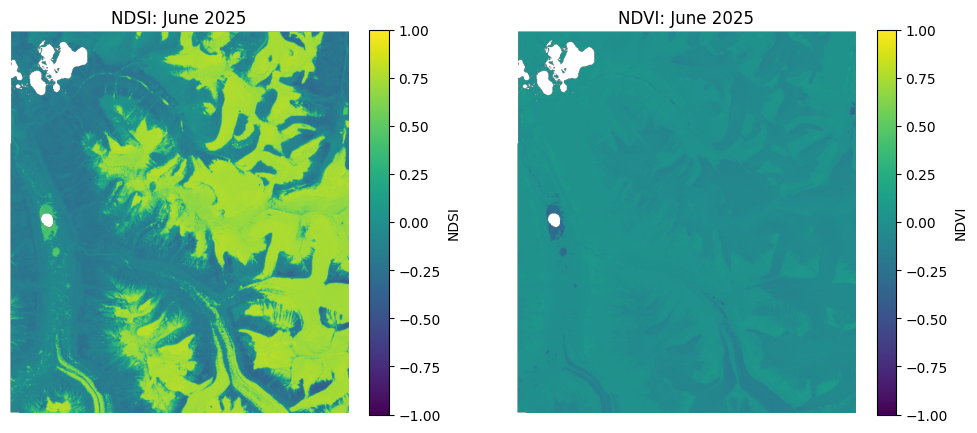

In [19]:
example_month = 6

example_processed_file = processed_indices_df.loc[
    processed_indices_df["month"] == example_month,
    "processed_file"
].iloc[0]

example_processed = np.load(example_processed_file)

NDSI_example = example_processed["NDSI"]
NDVI_example = example_processed["NDVI"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(NDSI_example, vmin=-1, vmax=1)
plt.title("NDSI: June 2025")
plt.colorbar(label="NDSI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(NDVI_example, vmin=-1, vmax=1)
plt.title("NDVI: June 2025")
plt.colorbar(label="NDVI")
plt.axis("off")

plt.show()

## 5. Create an NDSI-threshold snow-cover baseline

This step creates a simple snow-cover baseline from the masked NDSI images. Following a commonly used binary snow-cover threshold, **valid pixels with NDSI > 0.4 are classified as snow (Dozier, 1989; Kulkarni et al., 2010).**

The monthly snow-cover fraction is then calculated as the proportion of valid pixels classified as snow. These results provide a reference for comparing the K-means snow masks generated later on.

In [20]:
threshold_dir = os.path.join(processed_dir, "NDSI_Threshold")
os.makedirs(threshold_dir, exist_ok=True)

ndsi_threshold = 0.4

print("NDSI threshold:", ndsi_threshold)
print("Threshold output directory:", threshold_dir)

NDSI threshold: 0.4
Threshold output directory: /content/drive/MyDrive/GEOL0069/Final_Project/Data/Processed/NDSI_Threshold


In [21]:
threshold_records = []

for index, row in processed_indices_df.iterrows():

    # Load monthly processed data
    data = np.load(row["processed_file"])

    NDSI = data["NDSI"]
    valid_mask = data["valid_mask"]

    # Snow = valid pixel with NDSI > 0.4
    snow_mask = (NDSI > ndsi_threshold) & valid_mask

    # Snow-cover fraction is calculated only over valid pixels
    snow_pixels = np.sum(snow_mask)
    valid_pixels = np.sum(valid_mask)

    snow_fraction = snow_pixels / valid_pixels if valid_pixels > 0 else np.nan

    # Save monthly snow mask
    output_file = os.path.join(threshold_dir, f"ndsi_threshold_snow_mask_2025_{int(row['month']):02d}_{row['month_name']}.npz")

    np.savez_compressed(output_file, snow_mask=snow_mask, NDSI=NDSI, valid_mask=valid_mask)

    threshold_records.append({
        "month": row["month"],
        "month_name": row["month_name"],
        "date": row["date"],
        "cloud_cover": row["cloud_cover"],
        "valid_pixel_fraction": row["valid_pixel_fraction"],
        "snow_pixels": snow_pixels,
        "valid_pixels": valid_pixels,
        "ndsi_threshold_snow_fraction": snow_fraction,
        "snow_mask_file": output_file
    })

threshold_snow_df = pd.DataFrame(threshold_records)

display(threshold_snow_df)

,month,month_name,date,cloud_cover,valid_pixel_fraction,snow_pixels,valid_pixels,ndsi_threshold_snow_fraction,snow_mask_file
0,1,January,2025-01-31,0.002054,0.996275,129654,392140,0.330632,/content/drive/MyDrive/GEOL0069/Final_Project/...
1,2,February,2025-02-10,2.521034,0.937458,126255,368989,0.342165,/content/drive/MyDrive/GEOL0069/Final_Project/...
2,3,March,2025-03-27,0.010100,0.996253,147894,392131,0.377155,/content/drive/MyDrive/GEOL0069/Final_Project/...
3,4,April,2025-04-21,0.050823,0.996275,194656,392140,0.496394,/content/drive/MyDrive/GEOL0069/Final_Project/...
4,5,May,2025-05-08,19.816066,0.965224,253510,379918,0.667276,/content/drive/MyDrive/GEOL0069/Final_Project/...
5,6,June,2025-06-10,1.850641,0.982371,144889,386667,0.374713,/content/drive/MyDrive/GEOL0069/Final_Project/...
6,7,July,2025-07-07,12.159456,0.956667,133835,376550,0.355424,/content/drive/MyDrive/GEOL0069/Final_Project/...
7,8,August,2025-08-19,42.063248,0.475925,49794,187327,0.265813,/content/drive/MyDrive/GEOL0069/Final_Project/...
8,9,September,2025-09-05,23.067698,0.727860,128325,286490,0.447921,/content/drive/MyDrive/GEOL0069/Final_Project/...
9,10,October,2025-10-25,0.058397,0.996275,288845,392140,0.736586,/content/drive/MyDrive/GEOL0069/Final_Project/...


In [22]:
threshold_timeseries_path = os.path.join(metadata_dir, "ndsi_threshold_snow_fraction_2025.csv")

threshold_snow_df.to_csv(threshold_timeseries_path, index=False)

print("NDSI threshold snow-cover time series saved to:")
print(threshold_timeseries_path)

NDSI threshold snow-cover time series saved to:
/content/drive/MyDrive/GEOL0069/Final_Project/Data/Metadata/ndsi_threshold_snow_fraction_2025.csv


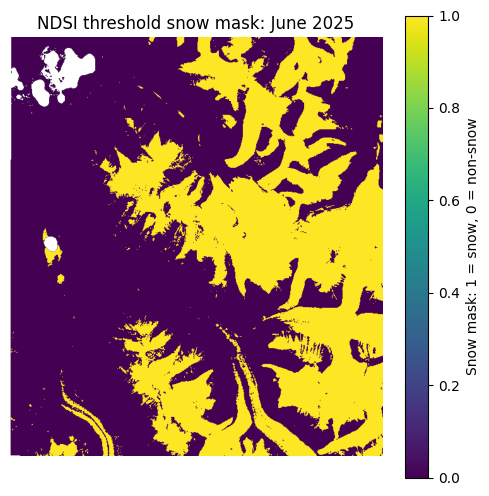

In [23]:
example_month = 6

example_row = threshold_snow_df.loc[
    threshold_snow_df["month"] == example_month
].iloc[0]

example_threshold = np.load(example_row["snow_mask_file"])

snow_mask_example = example_threshold["snow_mask"]
valid_mask_example = example_threshold["valid_mask"]

# Display invalid pixels as NaN, non-snow as 0, snow as 1
snow_display = np.full(snow_mask_example.shape, np.nan)
snow_display[valid_mask_example] = 0
snow_display[snow_mask_example] = 1

plt.figure(figsize=(6, 6))
plt.imshow(snow_display, vmin=0, vmax=1)
plt.title("NDSI threshold snow mask: June 2025")
plt.colorbar(label="Snow mask: 1 = snow, 0 = non-snow")
plt.axis("off")
plt.show()

## 6. K-means unsupervised snow classification

**K-means is an unsupervised clustering method that groups pixels with similar feature values without using labelled training data.**
In this project, it is used to separate the valid Sentinel-2 pixels into two main surface groups: snow-dominated and non-snow-dominated pixels.

The classification uses the processed feature stack from the previous step:

- B03
- B04
- B8A
- B11
- NDSI
- NDVI

Only valid pixels are included in this process.

After K-means has assigned each pixel to one of the two clusters, the snow cluster is identified as the one with the higher mean NDSI value. The output is a monthly K-means snow mask and a monthly snow-cover fraction for the AOI.

In [24]:
from sklearn.cluster import KMeans

kmeans_dir = os.path.join(processed_dir, "KMeans")
os.makedirs(kmeans_dir, exist_ok=True)

n_clusters = 2

print("K-means output directory:", kmeans_dir)
print("Number of clusters:", n_clusters)

K-means output directory: /content/drive/MyDrive/GEOL0069/Final_Project/Data/Processed/KMeans
Number of clusters: 2


In [25]:
def run_kmeans_snow_classification(processed_file, n_clusters=2):
    """
    Run K-means on one monthly processed Sentinel-2 file.
    """

    # Load processed data
    data = np.load(processed_file)

    feature_stack = data["feature_stack"]
    valid_mask = data["valid_mask"]

    # Keep only pixels that are valid and have finite values in all features
    valid_data_mask = valid_mask & np.all(np.isfinite(feature_stack), axis=2)

    # Reshape image stack into pixel-by-feature matrix
    X = feature_stack[valid_data_mask].reshape((-1, feature_stack.shape[-1]))

    # K-means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10).fit(X)

    labels = kmeans.labels_

    # Create an empty label image, using -1 for invalid pixels
    labels_image = np.full(feature_stack.shape[:2], -1, dtype=int)

    # Put cluster labels back into image shape
    labels_image[valid_data_mask] = labels

    # Summarise each cluster
    cluster_records = []

    for cluster_id in range(n_clusters):
        cluster_pixels = labels == cluster_id

        cluster_records.append({
            "cluster": cluster_id,
            "pixel_count": np.sum(cluster_pixels),
            "mean_B03": np.nanmean(X[cluster_pixels, 0]),
            "mean_B04": np.nanmean(X[cluster_pixels, 1]),
            "mean_B8A": np.nanmean(X[cluster_pixels, 2]),
            "mean_B11": np.nanmean(X[cluster_pixels, 3]),
            "mean_NDSI": np.nanmean(X[cluster_pixels, 4]),
            "mean_NDVI": np.nanmean(X[cluster_pixels, 5])
        })

    cluster_summary = pd.DataFrame(cluster_records)

    # Snow cluster is identified as the cluster with the highest mean NDSI
    snow_cluster = cluster_summary.sort_values(
        "mean_NDSI",
        ascending=False
    ).iloc[0]["cluster"]

    snow_cluster = int(snow_cluster)

    # Create snow mask
    snow_mask = labels_image == snow_cluster

    snow_pixels = np.sum(snow_mask)
    valid_pixels = np.sum(valid_data_mask)
    snow_fraction = snow_pixels / valid_pixels if valid_pixels > 0 else np.nan

    return labels_image, snow_mask, valid_data_mask, cluster_summary, snow_cluster, snow_fraction

In [26]:
kmeans_records = []
cluster_summary_records = []

for index, row in processed_indices_df.iterrows():

    labels_image, snow_mask, valid_data_mask, cluster_summary, snow_cluster, snow_fraction = (
        run_kmeans_snow_classification(
            processed_file=row["processed_file"],
            n_clusters=n_clusters
        )
    )

    output_file = os.path.join(
        kmeans_dir,
        f"kmeans_snow_mask_2025_{int(row['month']):02d}_{row['month_name']}.npz"
    )

    np.savez_compressed(
        output_file,
        labels_image=labels_image,
        snow_mask=snow_mask,
        valid_data_mask=valid_data_mask,
        snow_cluster=snow_cluster
    )

    kmeans_records.append({
        "month": row["month"],
        "month_name": row["month_name"],
        "date": row["date"],
        "cloud_cover": row["cloud_cover"],
        "valid_pixel_fraction": row["valid_pixel_fraction"],
        "kmeans_snow_cluster": snow_cluster,
        "kmeans_snow_fraction": snow_fraction,
        "kmeans_file": output_file
    })

    # Save cluster summary for this month
    cluster_summary["month"] = row["month"]
    cluster_summary["month_name"] = row["month_name"]
    cluster_summary["date"] = row["date"]
    cluster_summary_records.append(cluster_summary)

kmeans_snow_df = pd.DataFrame(kmeans_records)
kmeans_cluster_summary_df = pd.concat(cluster_summary_records, ignore_index=True)

display(kmeans_snow_df)

,month,month_name,date,cloud_cover,valid_pixel_fraction,kmeans_snow_cluster,kmeans_snow_fraction,kmeans_file
0,1,January,2025-01-31,0.002054,0.996275,1,0.315693,/content/drive/MyDrive/GEOL0069/Final_Project/...
1,2,February,2025-02-10,2.521034,0.937458,1,0.334322,/content/drive/MyDrive/GEOL0069/Final_Project/...
2,3,March,2025-03-27,0.010100,0.996253,0,0.374079,/content/drive/MyDrive/GEOL0069/Final_Project/...
3,4,April,2025-04-21,0.050823,0.996275,1,0.483049,/content/drive/MyDrive/GEOL0069/Final_Project/...
4,5,May,2025-05-08,19.816066,0.965224,1,0.646826,/content/drive/MyDrive/GEOL0069/Final_Project/...
5,6,June,2025-06-10,1.850641,0.982371,1,0.365666,/content/drive/MyDrive/GEOL0069/Final_Project/...
6,7,July,2025-07-07,12.159456,0.956667,1,0.339554,/content/drive/MyDrive/GEOL0069/Final_Project/...
7,8,August,2025-08-19,42.063248,0.475925,1,0.239576,/content/drive/MyDrive/GEOL0069/Final_Project/...
8,9,September,2025-09-05,23.067698,0.727860,0,0.414957,/content/drive/MyDrive/GEOL0069/Final_Project/...
9,10,October,2025-10-25,0.058397,0.996275,0,0.620972,/content/drive/MyDrive/GEOL0069/Final_Project/...


In [27]:
kmeans_snow_path = os.path.join(metadata_dir, "kmeans_snow_fraction_2025.csv")

kmeans_cluster_summary_path = os.path.join(metadata_dir, "kmeans_cluster_summary_2025.csv")

kmeans_snow_df.to_csv(kmeans_snow_path, index=False)
kmeans_cluster_summary_df.to_csv(kmeans_cluster_summary_path, index=False)

print("K-means snow fraction table saved to:")
print(kmeans_snow_path)

print("K-means cluster summary table saved to:")
print(kmeans_cluster_summary_path)

K-means snow fraction table saved to:
/content/drive/MyDrive/GEOL0069/Final_Project/Data/Metadata/kmeans_snow_fraction_2025.csv
K-means cluster summary table saved to:
/content/drive/MyDrive/GEOL0069/Final_Project/Data/Metadata/kmeans_cluster_summary_2025.csv


In [28]:
display(
    kmeans_cluster_summary_df[
        ["month", "month_name", "cluster", "pixel_count", "mean_NDSI", "mean_NDVI", "mean_B11"]
    ].head(12)
)

,month,month_name,cluster,pixel_count,mean_NDSI,mean_NDVI,mean_B11
0,1,January,0,268344,-0.055852,-0.002289,0.348954
1,1,January,1,123796,0.673974,-0.111803,0.144624
2,2,February,0,245628,-0.062553,-0.000321,0.353503
3,2,February,1,123361,0.672228,-0.121968,0.147916
4,3,March,0,146688,0.657792,-0.059857,0.181737
5,3,March,1,245443,-0.062887,0.009543,0.386961
6,4,April,0,202717,-0.035330,0.005603,0.400486
7,4,April,1,189423,0.680945,-0.048249,0.179493
8,5,May,0,134177,0.026150,0.014024,0.377257
9,5,May,1,245741,0.640123,-0.031280,0.222101


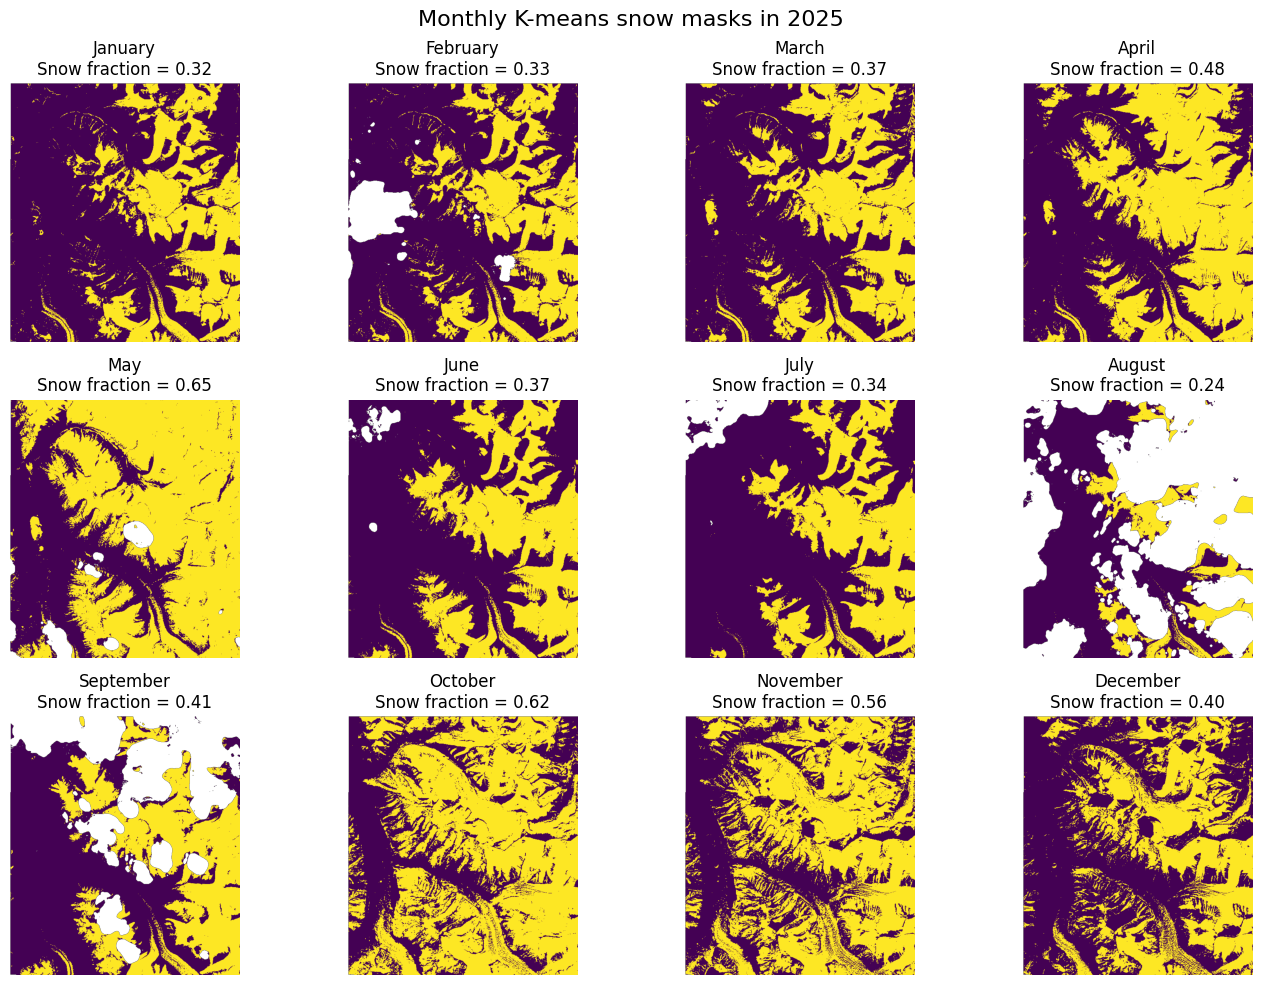

Saved: /content/drive/MyDrive/GEOL0069/Final_Project/Figures/fig_07_monthly_kmeans_snow_masks_2025.png


In [29]:
# 12-month K-means snow-mask panel
monthly_panel_path = os.path.join(figures_dir, "fig_03_monthly_kmeans_snow_masks_2025.png")

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i, row in kmeans_snow_df.iterrows():

    kmeans_data = np.load(row["kmeans_file"])

    snow_mask = kmeans_data["snow_mask"]
    valid_data_mask = kmeans_data["valid_data_mask"]

    snow_display = np.full(snow_mask.shape, np.nan)
    snow_display[valid_data_mask] = 0
    snow_display[snow_mask] = 1

    ax = axes[i]
    ax.imshow(snow_display, vmin=0, vmax=1)
    ax.set_title(
        f"{row['month_name']}\nSnow fraction = {row['kmeans_snow_fraction']:.2f}"
    )
    ax.axis("off")

plt.suptitle("Monthly K-means snow masks in 2025", fontsize=16)
plt.tight_layout()

plt.savefig(monthly_panel_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", monthly_panel_path)

## 7. GMM comparison (With a representative June example)

Gaussian Mixture Model (GMM) is another unsupervised learning method. K-means assigns pixels to groups based on distance to cluster centres, while **GMM represents each cluster as a probability distribution.** This makes GMM a useful comparison for checking whether the snow/non-snow classification is strongly affected by the choice of unsupervised learning approaches.

In this project, GMM is applied to the same feature stack used for K-means classification. **June 2025 is used as a representative low-cloud scene for this comparison.** The GMM snow cluster is identified as the one with the higher mean NDSI value, and the resulting snow mask is compared with the K-means snow mask.

The output is a one-month comparison of K-means and GMM snow-cover fraction, together with a pixel-level agreement score. **The agreement fraction** measures the proportion of valid pixels that receive the same snow/non-snow label from both methods, so **values closer to 1 indicate stronger agreement.**

In [30]:
from sklearn.mixture import GaussianMixture

# Select one representative month
gmm_month = 6

# Set output folder
gmm_dir = os.path.join(processed_dir, "GMM")
os.makedirs(gmm_dir, exist_ok=True)

# Load processed feature stack for the selected month
gmm_row = processed_indices_df.loc[
    processed_indices_df["month"] == gmm_month
].iloc[0]

data = np.load(gmm_row["processed_file"])

feature_stack = data["feature_stack"]
valid_mask = data["valid_mask"]

# Keep only valid pixels with finite feature values
valid_data_mask = valid_mask & np.all(np.isfinite(feature_stack), axis=2)

# Reshape image stack into pixel-by-feature matrix
X = feature_stack[valid_data_mask].reshape((-1, feature_stack.shape[-1]))

# Apply GMM clustering using the same feature matrix as K-means
gmm = GaussianMixture(n_components=2, random_state=0).fit(X)

labels = gmm.predict(X)

# Put labels back into image shape
gmm_labels_image = np.full(feature_stack.shape[:2], -1, dtype=int)
gmm_labels_image[valid_data_mask] = labels

# Summarise each GMM cluster
gmm_cluster_records = []

for cluster_id in range(2):
    cluster_pixels = labels == cluster_id

    gmm_cluster_records.append({
        "cluster": cluster_id,
        "pixel_count": np.sum(cluster_pixels),
        "mean_B03": np.nanmean(X[cluster_pixels, 0]),
        "mean_B04": np.nanmean(X[cluster_pixels, 1]),
        "mean_B8A": np.nanmean(X[cluster_pixels, 2]),
        "mean_B11": np.nanmean(X[cluster_pixels, 3]),
        "mean_NDSI": np.nanmean(X[cluster_pixels, 4]),
        "mean_NDVI": np.nanmean(X[cluster_pixels, 5])
    })

gmm_cluster_summary = pd.DataFrame(gmm_cluster_records)

# Snow cluster = cluster with higher mean NDSI
gmm_snow_cluster = int(
    gmm_cluster_summary.sort_values(
        "mean_NDSI",
        ascending=False
    ).iloc[0]["cluster"]
)

gmm_snow_mask = gmm_labels_image == gmm_snow_cluster

gmm_snow_fraction = (np.sum(gmm_snow_mask) / np.sum(valid_data_mask))

# Save GMM output
gmm_output_file = os.path.join(gmm_dir, f"gmm_snow_mask_2025_{gmm_month:02d}_June.npz")

np.savez_compressed(
    gmm_output_file,
    labels_image=gmm_labels_image,
    snow_mask=gmm_snow_mask,
    valid_data_mask=valid_data_mask,
    snow_cluster=gmm_snow_cluster
)

display(gmm_cluster_summary)

print("GMM snow cluster:", gmm_snow_cluster)
print("GMM snow fraction:", gmm_snow_fraction)
print("GMM output saved to:", gmm_output_file)

,cluster,pixel_count,mean_B03,mean_B04,mean_B8A,mean_B11,mean_NDSI,mean_NDVI
0,0,245077,0.342871,0.370138,0.376246,0.406824,-0.078588,0.008954
1,1,141590,0.951825,0.937340,0.831465,0.165331,0.698360,-0.061329


GMM snow cluster: 1
GMM snow fraction: 0.36618071880972514
GMM output saved to: /content/drive/MyDrive/GEOL0069/Final_Project/Data/Processed/GMM/gmm_snow_mask_2025_06_June.npz


In [31]:
# Load K-means snow mask for the same month
kmeans_row = kmeans_snow_df.loc[
    kmeans_snow_df["month"] == gmm_month
].iloc[0]

kmeans_data = np.load(kmeans_row["kmeans_file"])

kmeans_snow_mask = kmeans_data["snow_mask"]
kmeans_valid_mask = kmeans_data["valid_data_mask"]

# Compare only pixels valid in both methods
agreement_valid_mask = valid_data_mask & kmeans_valid_mask

# Snow fraction comparison
gmm_comparison_df = pd.DataFrame({
    "method": ["K-means", "GMM"],
    "month": [gmm_month, gmm_month],
    "month_name": ["June", "June"],
    "snow_fraction": [
        kmeans_row["kmeans_snow_fraction"],
        gmm_snow_fraction
    ]
})

display(gmm_comparison_df)

# Agreement matrix: K-means snow/non-snow vs GMM snow/non-snow
agreement_matrix = pd.crosstab(
    pd.Series(
        kmeans_snow_mask[agreement_valid_mask].astype(int),
        name="K-means"
    ),
    pd.Series(
        gmm_snow_mask[agreement_valid_mask].astype(int),
        name="GMM"
    )
)

display(agreement_matrix)

agreement_fraction = np.trace(agreement_matrix.values) / agreement_matrix.values.sum()

print("K-means/GMM agreement fraction:", agreement_fraction)

,method,month,month_name,snow_fraction
0,K-means,6,June,0.365666
1,GMM,6,June,0.366181


GMM,0,1
K-means,,
0,244174,1102
1,903,140488


K-means/GMM agreement fraction: 0.9948146596425348


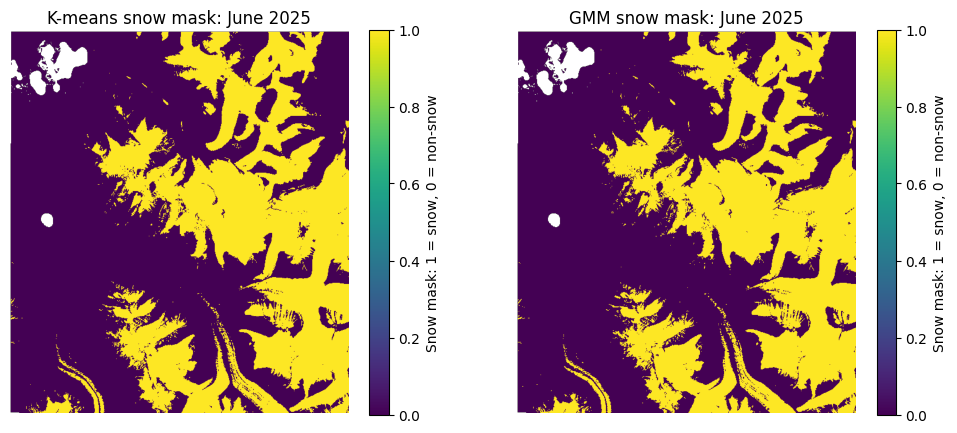

In [32]:
# Prepare display arrays
kmeans_display = np.full(kmeans_snow_mask.shape, np.nan)
kmeans_display[agreement_valid_mask] = 0
kmeans_display[kmeans_snow_mask & agreement_valid_mask] = 1

gmm_display = np.full(gmm_snow_mask.shape, np.nan)
gmm_display[agreement_valid_mask] = 0
gmm_display[gmm_snow_mask & agreement_valid_mask] = 1

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(kmeans_display, vmin=0, vmax=1)
plt.title("K-means snow mask: June 2025")
plt.colorbar(label="Snow mask: 1 = snow, 0 = non-snow")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gmm_display, vmin=0, vmax=1)
plt.title("GMM snow mask: June 2025")
plt.colorbar(label="Snow mask: 1 = snow, 0 = non-snow")
plt.axis("off")

plt.show()

For the representative June scene, **GMM and K-means produced almost identical results** estimating a snow-cover fraction of 0.366, and the pixel-level agreement was 99.5%. This high agreement suggests that, for this example (June), **the snow/non-snow separation is not strongly sensitive to the choice between K-means and GMM.** K-means is therefore retained as the main classification method for the full monthly analysis because it is simpler to implement and easier to interpret.

## 8. Monthly snow-cover fraction time series

This step combines the monthly snow-cover fractions from the NDSI-threshold baseline and the K-means classification into one time-series table. The saved table provides the main monthly input for the Gaussian Process interpolation later on.

The comparison line graph also shows how the two approaches estimate the seasonal snow-cover pattern differently throughout 2025.

In [33]:
# Combine NDSI-threshold and K-means snow-cover fractions
snow_fraction_timeseries = threshold_snow_df[
    [
        "month",
        "month_name",
        "date",
        "cloud_cover",
        "valid_pixel_fraction",
        "ndsi_threshold_snow_fraction"
    ]
].merge(
    kmeans_snow_df[
        [
            "month",
            "kmeans_snow_fraction"
        ]
    ],
    on="month",
    how="left"
)

# Save the final monthly time-series table
snow_fraction_timeseries_path = os.path.join(metadata_dir, "snow_fraction_timeseries_2025.csv")

snow_fraction_timeseries.to_csv(snow_fraction_timeseries_path, index=False)

display(snow_fraction_timeseries)

print("Snow-cover fraction time series saved to:")
print(snow_fraction_timeseries_path)

,month,month_name,date,cloud_cover,valid_pixel_fraction,ndsi_threshold_snow_fraction,kmeans_snow_fraction
0,1,January,2025-01-31,0.002054,0.996275,0.330632,0.315693
1,2,February,2025-02-10,2.521034,0.937458,0.342165,0.334322
2,3,March,2025-03-27,0.010100,0.996253,0.377155,0.374079
3,4,April,2025-04-21,0.050823,0.996275,0.496394,0.483049
4,5,May,2025-05-08,19.816066,0.965224,0.667276,0.646826
5,6,June,2025-06-10,1.850641,0.982371,0.374713,0.365666
6,7,July,2025-07-07,12.159456,0.956667,0.355424,0.339554
7,8,August,2025-08-19,42.063248,0.475925,0.265813,0.239576
8,9,September,2025-09-05,23.067698,0.727860,0.447921,0.414957
9,10,October,2025-10-25,0.058397,0.996275,0.736586,0.620972


Snow-cover fraction time series saved to:
/content/drive/MyDrive/GEOL0069/Final_Project/Data/Metadata/snow_fraction_timeseries_2025.csv


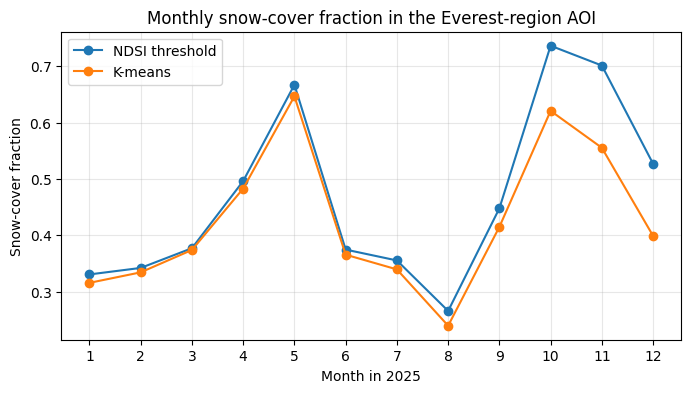

In [34]:
plt.figure(figsize=(8, 4))

plt.plot(
    snow_fraction_timeseries["month"],
    snow_fraction_timeseries["ndsi_threshold_snow_fraction"],
    marker="o",
    label="NDSI threshold"
)

plt.plot(
    snow_fraction_timeseries["month"],
    snow_fraction_timeseries["kmeans_snow_fraction"],
    marker="o",
    label="K-means"
)

plt.xticks(range(1, 13))
plt.xlabel("Month in 2025")
plt.ylabel("Snow-cover fraction")
plt.title("Monthly snow-cover fraction in the Everest-region AOI")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The NDSI-threshold and K-means curves show a similar seasonal pattern, but their values are not the same. This is within expectation because the NDSI method uses a fixed threshold, while K-means classifies pixels using multiple spectral and index features. Differences are most likely to occur in mixed pixels, shadowed areas, or pixels with intermediate NDSI values.

For the next notebook, the K-means snow-cover fraction is used as the main monthly time series because it provides a data-driven classification while remaining interpretable.

## Optional: Exporting final figures

This optional section saves the main figures from this notebook to the project `figures` folder for demonstration.

The plots have already been produced in earlier steps, so the code below mainly repeats the plotting commands with added saving paths. **This section can be skipped if the figure files are not needed.**

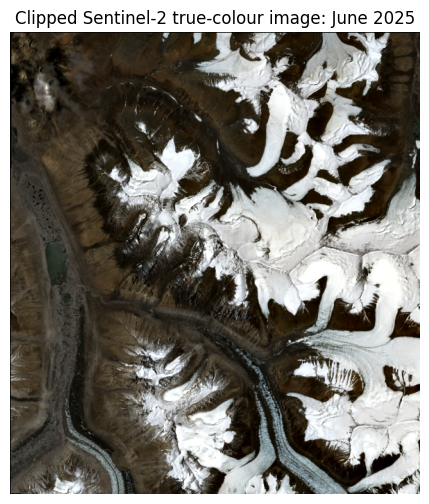

Saved: /content/drive/MyDrive/GEOL0069/Final_Project/Figures/fig_01_aoi_true_colour_june_2025.png


In [35]:
# Save true-colour RGB image for the example month
example_month = 6

example_file = clipped_files_df.loc[
    clipped_files_df["month"] == example_month,
    "clipped_file"
].iloc[0]

example_data = np.load(example_file)

red = example_data["B04"].astype(float) / 10000
green = example_data["B03"].astype(float) / 10000
blue = example_data["B02"].astype(float) / 10000

rgb = np.dstack([red, green, blue])

# Percentile stretch for display only
lower = np.nanpercentile(rgb, 2)
upper = np.nanpercentile(rgb, 98)

rgb_stretched = (rgb - lower) / (upper - lower)
rgb_stretched = np.clip(rgb_stretched, 0, 1)

rgb_figure_path = os.path.join(figures_dir, "fig_01_aoi_true_colour_june_2025.png")

plt.figure(figsize=(6, 6))
plt.imshow(rgb_stretched)
plt.title("Clipped Sentinel-2 true-colour image: June 2025")
plt.axis("off")
plt.savefig(rgb_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", rgb_figure_path)

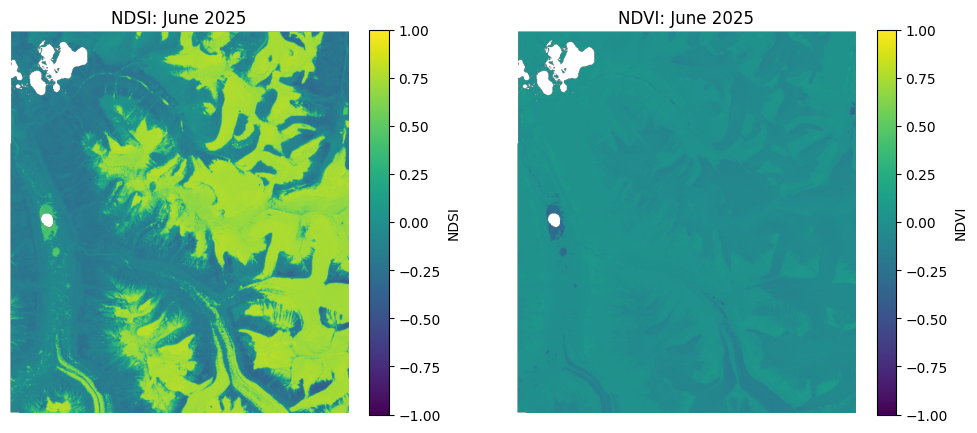

Saved: /content/drive/MyDrive/GEOL0069/Final_Project/Figures/fig_02_ndsi_ndvi_june_2025.png


In [36]:
# Save NDSI and NDVI maps for the example month
example_processed_file = processed_indices_df.loc[
    processed_indices_df["month"] == example_month,
    "processed_file"
].iloc[0]

example_processed = np.load(example_processed_file)

NDSI_example = example_processed["NDSI"]
NDVI_example = example_processed["NDVI"]

indices_figure_path = os.path.join(figures_dir, "fig_02_ndsi_ndvi_june_2025.png")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(NDSI_example, vmin=-1, vmax=1)
plt.title("NDSI: June 2025")
plt.colorbar(label="NDSI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(NDVI_example, vmin=-1, vmax=1)
plt.title("NDVI: June 2025")
plt.colorbar(label="NDVI")
plt.axis("off")

plt.savefig(indices_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", indices_figure_path)

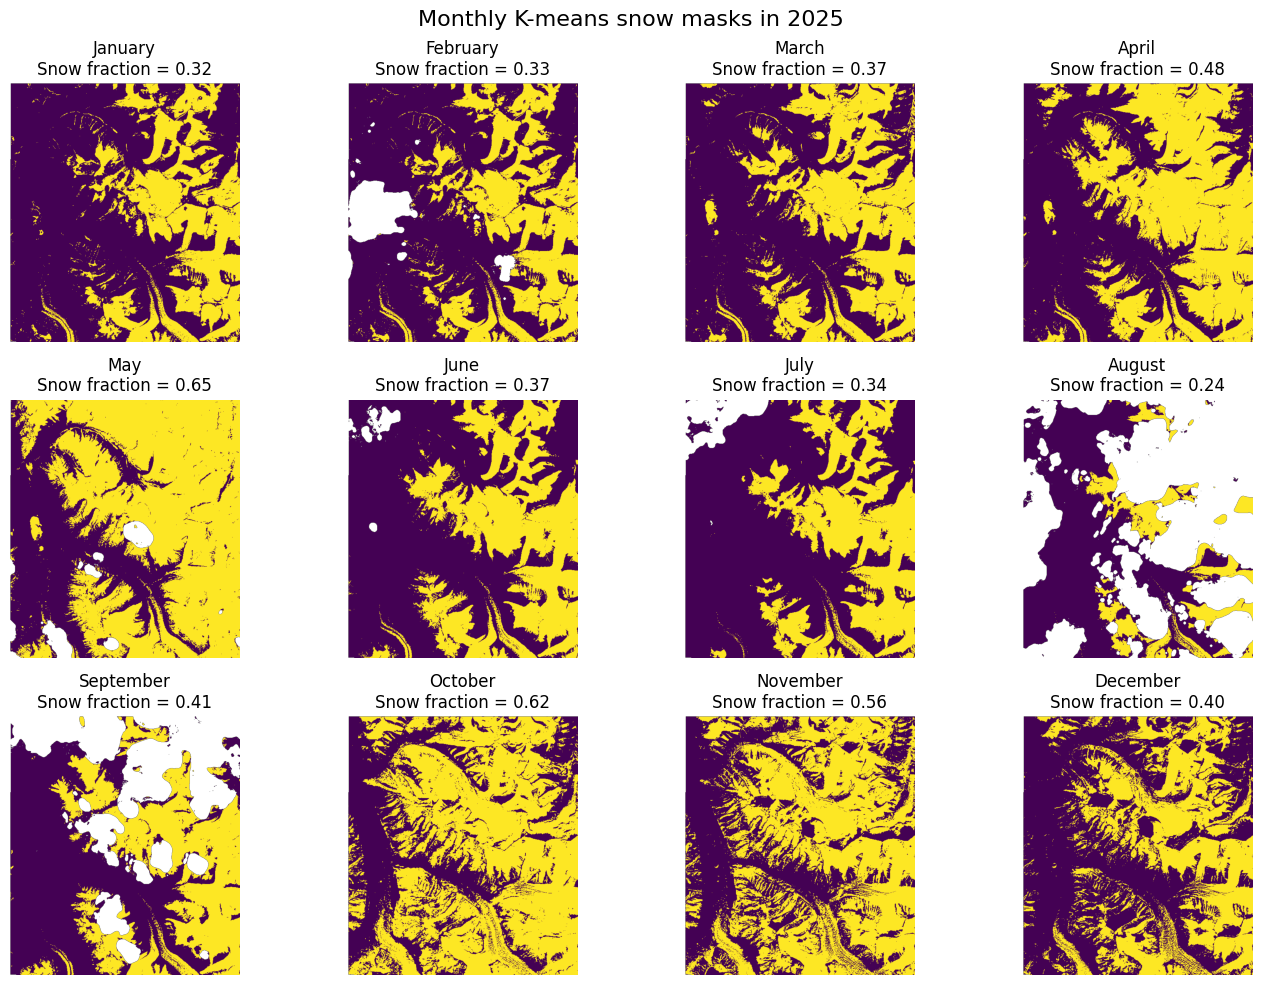

Saved: /content/drive/MyDrive/GEOL0069/Final_Project/Figures/fig_03_monthly_kmeans_snow_masks_2025.png


In [37]:
# Save 12-month K-means snow-mask panel
monthly_panel_path = os.path.join(figures_dir, "fig_03_monthly_kmeans_snow_masks_2025.png")

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i, row in kmeans_snow_df.iterrows():

    kmeans_data = np.load(row["kmeans_file"])

    snow_mask = kmeans_data["snow_mask"]
    valid_data_mask = kmeans_data["valid_data_mask"]

    snow_display = np.full(snow_mask.shape, np.nan)
    snow_display[valid_data_mask] = 0
    snow_display[snow_mask] = 1

    ax = axes[i]
    ax.imshow(snow_display, vmin=0, vmax=1)
    ax.set_title(
        f"{row['month_name']}\nSnow fraction = {row['kmeans_snow_fraction']:.2f}"
    )
    ax.axis("off")

plt.suptitle("Monthly K-means snow masks in 2025", fontsize=16)
plt.tight_layout()

plt.savefig(monthly_panel_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", monthly_panel_path)

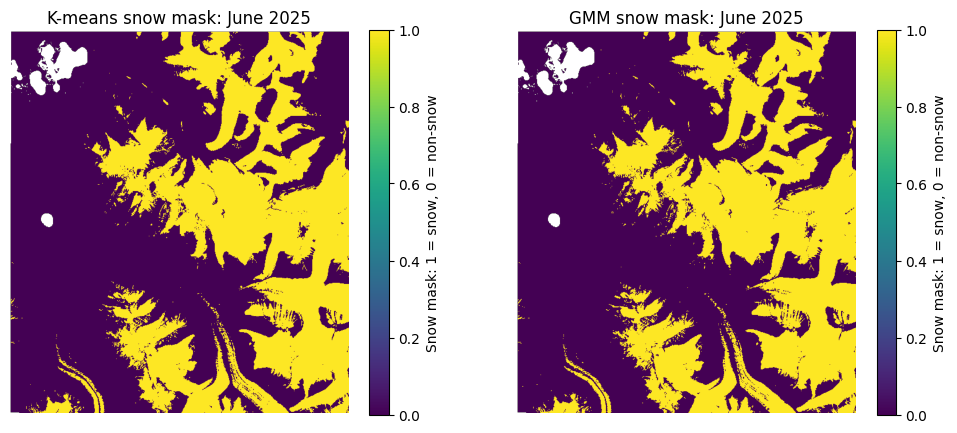

Saved: /content/drive/MyDrive/GEOL0069/Final_Project/Figures/fig_04_kmeans_vs_gmm_june_2025.png


In [38]:
# Save one-month K-means vs GMM comparison
gmm_data = np.load(gmm_output_file)

gmm_snow_mask = gmm_data["snow_mask"]
gmm_valid_mask = gmm_data["valid_data_mask"]

# Compare only pixels valid in both methods
agreement_valid_mask = kmeans_valid_mask & gmm_valid_mask

kmeans_display = np.full(kmeans_snow_mask.shape, np.nan)
kmeans_display[agreement_valid_mask] = 0
kmeans_display[kmeans_snow_mask & agreement_valid_mask] = 1

gmm_display = np.full(gmm_snow_mask.shape, np.nan)
gmm_display[agreement_valid_mask] = 0
gmm_display[gmm_snow_mask & agreement_valid_mask] = 1

gmm_figure_path = os.path.join(figures_dir, "fig_04_kmeans_vs_gmm_june_2025.png")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(kmeans_display, vmin=0, vmax=1)
plt.title("K-means snow mask: June 2025")
plt.colorbar(label="Snow mask: 1 = snow, 0 = non-snow")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gmm_display, vmin=0, vmax=1)
plt.title("GMM snow mask: June 2025")
plt.colorbar(label="Snow mask: 1 = snow, 0 = non-snow")
plt.axis("off")

plt.savefig(gmm_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", gmm_figure_path)

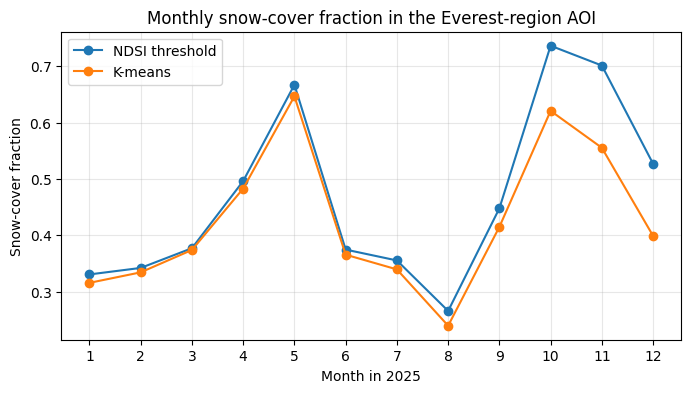

Saved: /content/drive/MyDrive/GEOL0069/Final_Project/Figures/fig_05_monthly_snow_fraction_timeseries_2025.png


In [39]:
# Save final monthly snow-cover fraction time series figure
timeseries_figure_path = os.path.join(figures_dir, "fig_05_monthly_snow_fraction_timeseries_2025.png")

plt.figure(figsize=(8, 4))

plt.plot(
    snow_fraction_timeseries["month"],
    snow_fraction_timeseries["ndsi_threshold_snow_fraction"],
    marker="o",
    label="NDSI threshold"
)

plt.plot(
    snow_fraction_timeseries["month"],
    snow_fraction_timeseries["kmeans_snow_fraction"],
    marker="o",
    label="K-means"
)

plt.xticks(range(1, 13))
plt.xlabel("Month in 2025")
plt.ylabel("Snow-cover fraction")
plt.title("Monthly snow-cover fraction in the Everest-region AOI")
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(timeseries_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", timeseries_figure_path)